## 调整class_weight,1类点只有候选点和pareto范围内的点

In [2]:
from sklearn.metrics import recall_score, make_scorer, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns    
import pandas as pd
import math
from matplotlib import cm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score # 导入accuracy_score函数
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, make_scorer, classification_report

# df = pd.read_csv("decision tree.csv")
# X = df[['Ar', 'VE', 'EN', 'BP', 'Co']].to_numpy()
# y = df.iloc[:, -1].to_numpy()
# X=np.vstack((X[:,0]/100,X[:,1],X[:,2],X[:,3]/920,X[:,4])).T   # 对部分特征进行放缩  原子质量 价电子 电负性 沸点 内聚能
# # X=np.delete(X,[0,2,3],axis=1)
# original_indices = np.arange(len(df)) 

# 删减特征后的dataframe
df = pd.read_csv("decision tree.csv")
# 删除指定行但保持原始索引
rows_to_delete = [339,351,354,365,371,375,408,434,511,516,542,605,564,298]
df_filtered = df.drop(rows_to_delete)  # 不使用reset_index
# 获取剩余数据的原始索引
original_indices = df_filtered.index.values
# 处理数据
X = df_filtered[['Ar', 'VE', 'EN', 'BP', 'Co']].to_numpy()
y = df_filtered.iloc[:, -1].to_numpy()
X = np.vstack((X[:,0]/100, X[:,1], X[:,2], X[:,3]/920, X[:,4])).T

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, original_indices, test_size=0.2, random_state=12)
# clf = dtc(max_depth=4,min_samples_split=10,max_features=3,class_weight={0:0.6,1:4},min_impurity_decrease=0)

clf = dtc(max_depth=6,min_samples_split=8,max_features=3,class_weight={0:1,1:5},min_impurity_decrease=0,random_state=30)  #b保存有图片
# clf = dtc(max_depth=6,min_samples_split=6,max_features=3,class_weight={0:1,1:5},min_impurity_decrease=0)
clf = clf.fit(X_train, y_train)
y_train_pred=clf.predict(X_train)
score_tr = clf.score(X_train,y_train)
score_te = clf.score(X_test,y_test)
score_tr,score_te
# print(np.unique(y_train,return_counts=True))
print("\n训练集评估报告：")
print(classification_report(y_train, y_train_pred, digits=4))


训练集评估报告：
              precision    recall  f1-score   support

           0     0.9933    0.9801    0.9866       452
           1     0.7692    0.9091    0.8333        33

    accuracy                         0.9753       485
   macro avg     0.8813    0.9446    0.9100       485
weighted avg     0.9780    0.9753    0.9762       485



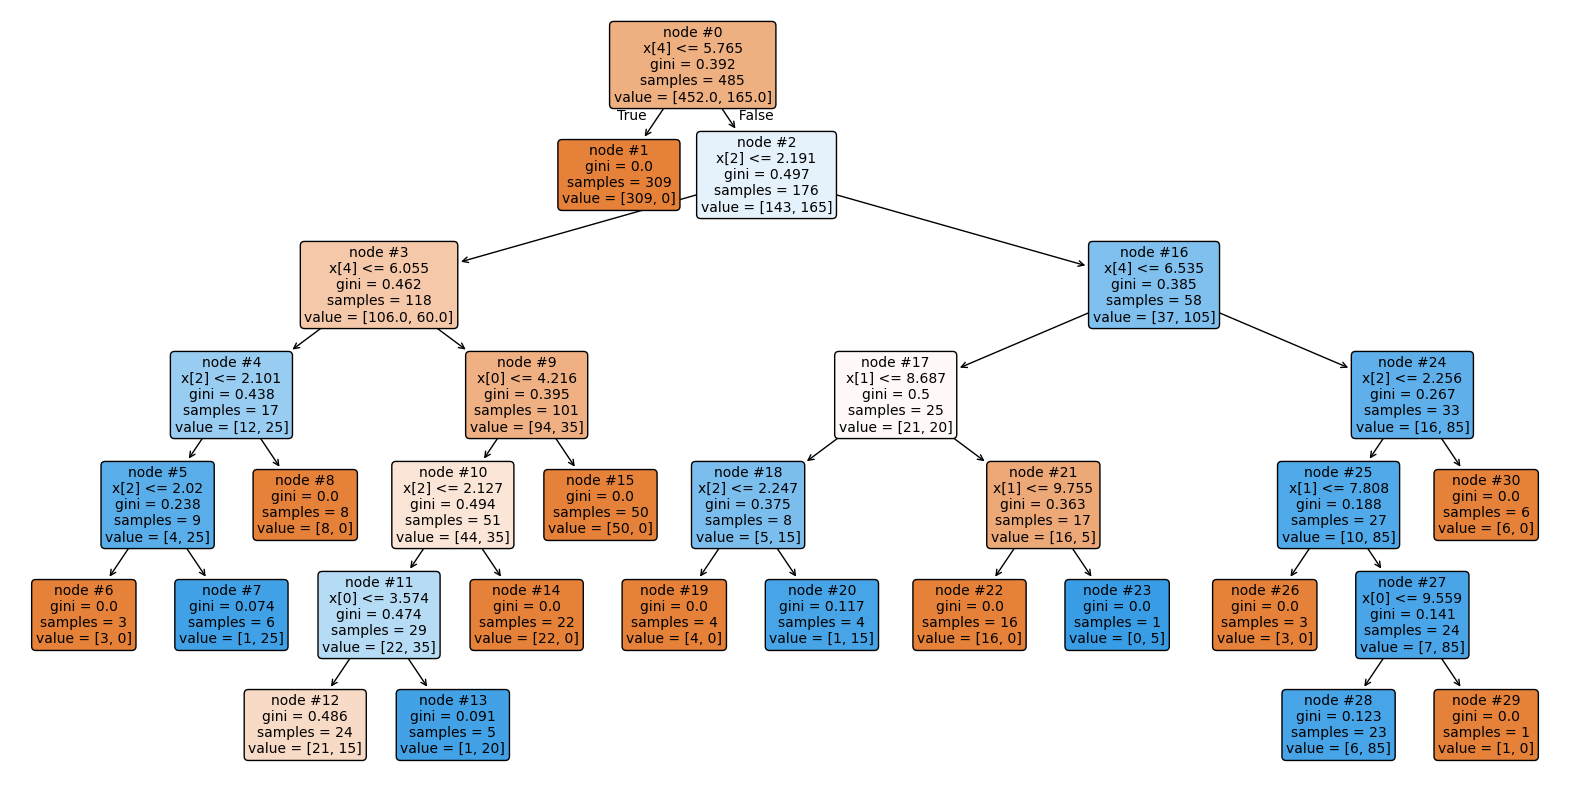

In [3]:
plt.figure(figsize=(20,10
                   ))      #设置画布大小（单位为英寸）
tree.plot_tree(clf             #训练好的决策树评估器
               ,node_ids=True  #显示节点id
               ,filled=True    #给节点填充颜色
               ,rounded=True   #节点方框变成圆角
               ,fontsize=10    #节点中文本的字体大小
              )

plt.savefig("决策树-n.png",transparent=True)      #保存图片一定要在plt.show()之前
plt.show()

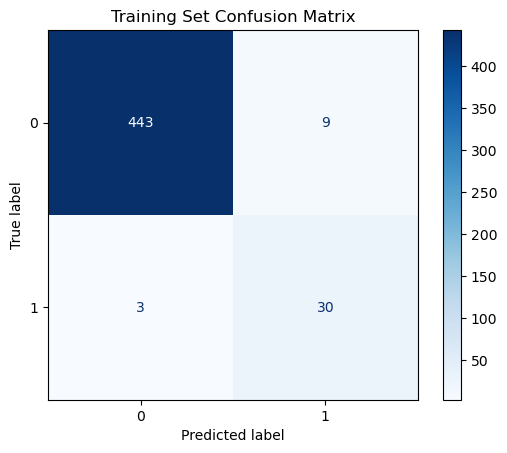

,name,Ar,VE,AR,EN,Ea,1st,BP,Co,ρ0*λ/10^(-16)Ωm2,class_,Pred_Label
Original_Index,,,,,,,,,,,,
575,Ir3Mo,672.601000,8.572035,181.426552,2.194294,139.715977,852.082386,4731.100238,6.94,3.78,0,1
7,Nb,92.906370,5.000000,198.000000,1.600000,86.100000,652.100000,5017.000000,7.56,3.91,1,0
463,Rh3Nb,401.622840,8.074690,178.783185,2.122697,104.240673,704.062267,4210.662450,6.26,3.65,0,1
578,Ir3Rh,679.556490,9.000000,178.939987,2.212114,144.745926,855.725712,4590.001540,6.60,3.81,0,1
436,Rh2Ru,306.880980,8.670654,174.646730,2.253652,106.933494,716.571214,4117.852396,5.95,3.40,0,1
220,Co2Ir,310.083388,9.000000,169.356867,2.078364,117.816231,834.538616,4130.452027,5.86,3.84,0,1
28,OsRu,291.300000,8.000000,182.571267,2.200000,104.434583,794.964346,4985.918847,7.40,4.20,0,1
526,IrOs,382.447000,8.502598,182.487011,2.200000,128.666639,860.103910,4991.482917,7.26,3.79,0,1
191,CoOs,249.163194,8.236524,177.194692,2.124312,96.071362,821.172652,4791.846467,7.06,3.56,1,0


In [4]:
y_pred_train = clf.predict(X_train)

# 混淆矩阵用来可视化模型分类情况
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Training Set Confusion Matrix")
plt.savefig('Training Set Confusion Matrix',transparent=True)
plt.show()

# 构造只包含训练集部分的特征 DataFrame
X_train_df = pd.DataFrame(X_train, columns=['Ar', 'VE', 'EN', 'BP', 'Co'])
# 添加预测结果
results_df = X_train_df.copy()
results_df = pd.DataFrame({
    'True_Label': y_train,
    'Pred_Label': y_pred_train,
    'Original_Index':idx_train
})
results_df['Is_Correct'] = results_df['True_Label'] == results_df['Pred_Label']

# 找出错误预测的样本
error_samples = results_df[~results_df['Is_Correct']]
error_samples = error_samples.set_index('Original_Index')

pd.options.display.width=800

error_indices = error_samples.index.tolist()
error_detail = df.loc[error_samples.index].copy()
error_detail['Pred_Label'] = error_samples['Pred_Label'].values
display(error_detail)


     ρ0*λ/10^(-16)Ωm2
0                8.80
1                5.01
2                6.66
3                4.82
4                4.07
..                ...
616              3.82
617              3.82
618              4.20
619              3.85
620              3.79

[621 rows x 1 columns]


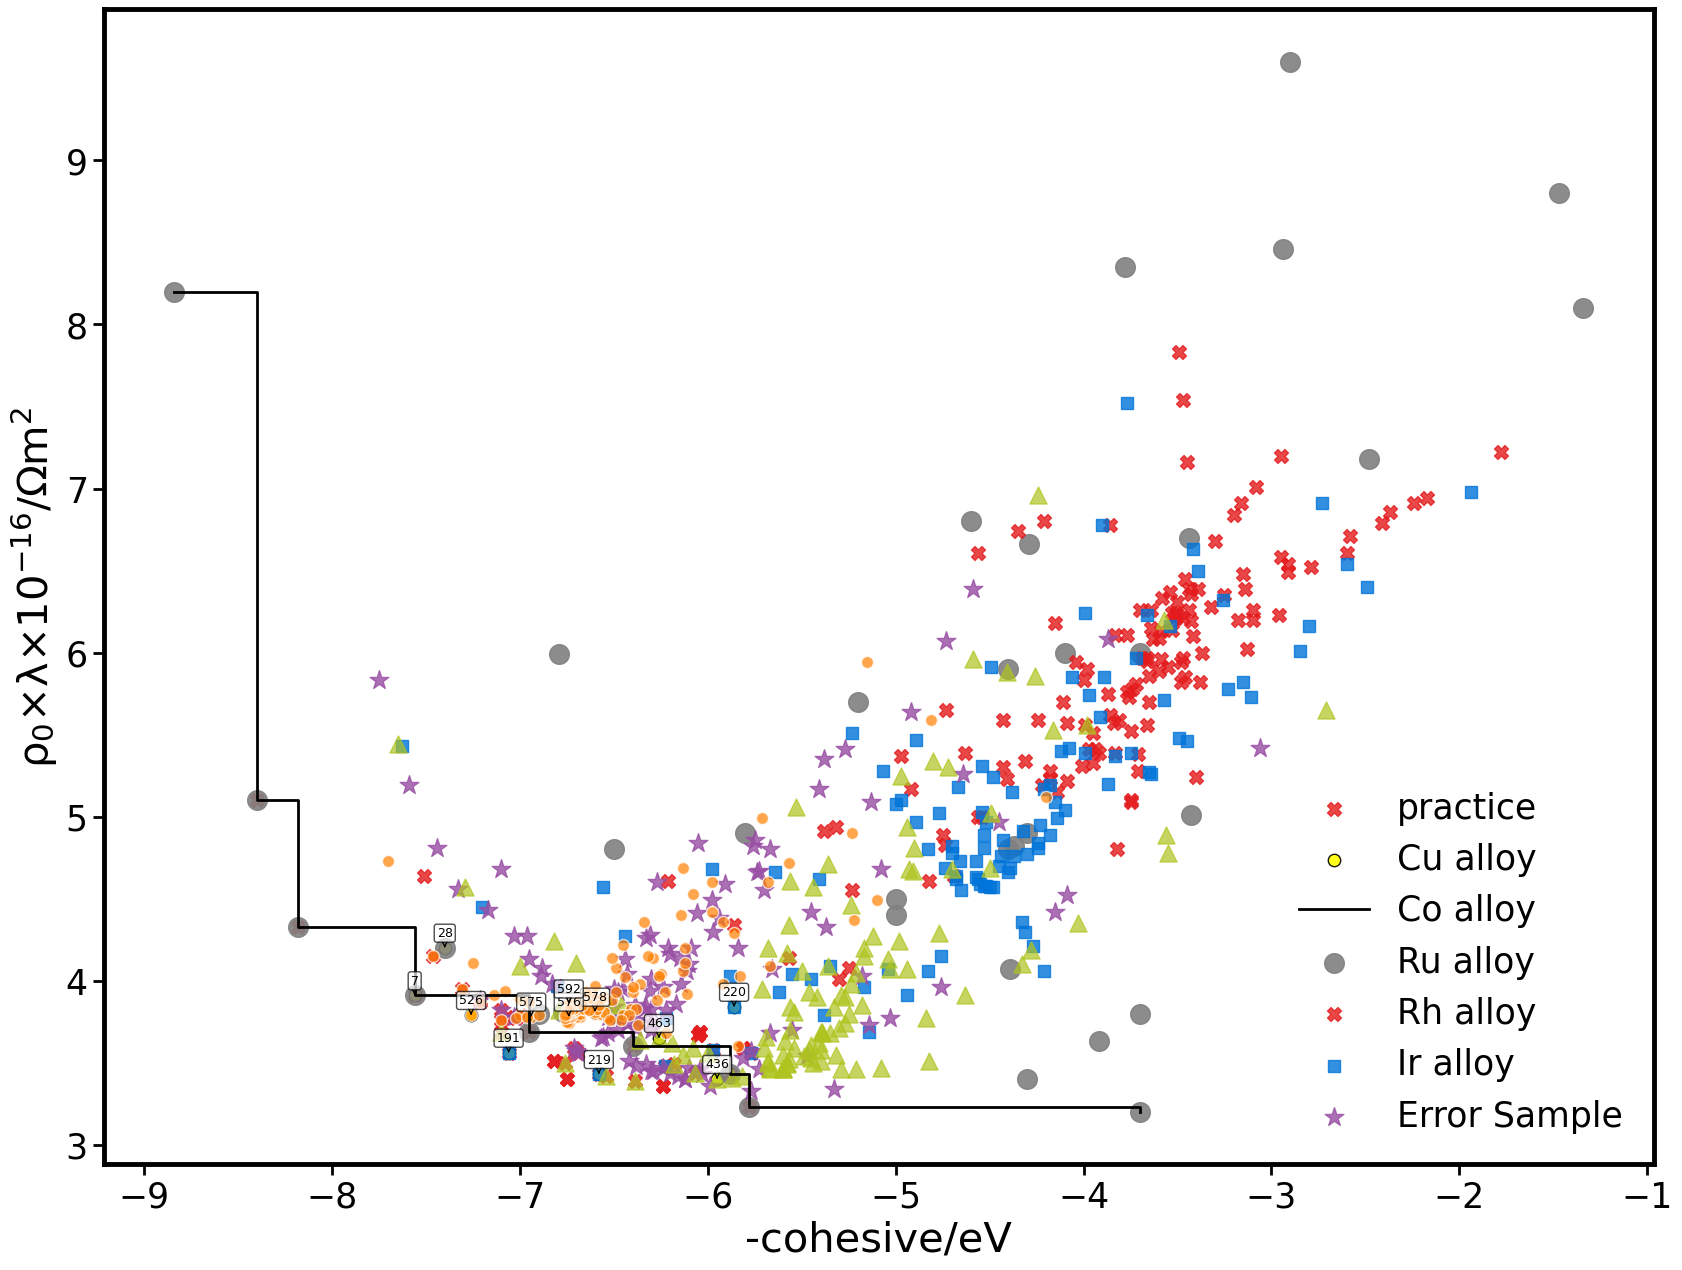

In [7]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from matplotlib.backend_bases import MouseButton
from scipy.stats import pearsonr
from sklearn.svm import SVR
import pandas as pd
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# 1. 读取原始数据并添加索引列
df = pd.read_csv("decision tree.csv")
df['original_index'] = df.index  # 保存原始索引以便追踪
X_ = df.iloc[:,[8]]
y_ = df.iloc[:,[9]] 
print(y_)

# # 删减特征后的dataframe
# df1 = pd.read_csv("decision tree.csv")
# # 删除指定行但保持原始索引
# rows_to_delete = [339,351,354,365,371,375,408,434,511,516,542,605,564,298]
# df = df1.drop(rows_to_delete)  # 不使用reset_index
# # original_indices = df.index.values
# # 处理数据
# X_ = df.iloc[:,[8]]
# y_ = df.iloc[:,[9]] 

error_indices = error_samples.index.tolist()

# 读取pareto数据文件
pareto = np.loadtxt('pareto', delimiter=',')

x_error=X_.loc[error_indices]
y_error=y_.loc[error_indices]
best=df[df['class_'] == 1]
x_best=best.iloc[:,[8]]
y_best=best.iloc[:,[9]]

plt.figure(figsize=(20,15))
ax = plt.gca()  # 获取当前轴对象
ax.set_xlim(-9.215, -0.9650000000000001)
ax.set_ylim(2.8800000000000003, 9.92)
ax.spines['bottom'].set_linewidth(3.5)
ax.spines['left'].set_linewidth(3.5)
ax.spines['top'].set_linewidth(3.5)
ax.spines['right'].set_linewidth(3.5)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)

# 特别标出错误样本
plt.scatter(-x_best, y_best,s = 100,c='#E41A1C', marker='X', alpha=0.8,label='best')  # 绘制 Cu 预测数据点
plt.scatter(-x_error.iloc[:, 0], y_error.iloc[:, 0], 
           c='yellow', marker='o', edgecolors='k',alpha=0.9, s=80,label='error')
plt.plot(pareto[:,0],pareto[:,1],c='k',linewidth=2)

plt.xlabel('-cohesive/eV',fontsize=30)
plt.ylabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$',fontsize=30)

#标注序号
for i, idx in enumerate(error_indices):
    plt.annotate(str(idx), 
                xy=(-x_error.iloc[i, 0], y_error.iloc[i, 0]),
                xytext=(-x_error.iloc[i, 0], y_error.iloc[i, 0] + 0.05),
                fontsize=9,
                ha='center',
                va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),  # 添加背景框
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
# plt.tight_layout()
# plt.savefig('error.png', dpi=300, bbox_inches='tight',transparent=True)
# plt.show()


#配色第三版
# 每一类图的大致数据划分
x_values=X_.iloc[:38]
y_values=y_.iloc[:38]
X1=X_.iloc[38:173]  # [:134]
X2=X_.iloc[173:287]  #[134:249]
X3=X_.iloc[287:397]   #[249:360]
X4=X_.iloc[397:510]    #[360:472]
X5=X_.iloc[510:]    #[472:582]
y1=y_.iloc[38:173]
y2=y_.iloc[173:287]
y3=y_.iloc[287:397]
y4=y_.iloc[397:510]
y5=y_.iloc[510:]
plt.scatter(-x_values, y_values,s = 200,c='#808080', alpha=0.9)  # 绘制实验数据点
plt.scatter(-X1, y1,s = 100,c='#E41A1C', marker='X', alpha=0.8)  # 绘制 Cu 预测数据点
plt.scatter(-X2, y2,s = 80,c='#0074D9', marker='s', alpha=0.8)  # 绘制 Co 预测数据点
plt.scatter(-X3, y3,s = 200,c='#984EA3', marker='*', alpha=0.8)  # 绘制 Ru 预测数据点 
plt.scatter(-X4, y4,s = 150,c='#AFC41F', marker='^', alpha=0.7)  # 绘制预 Rh测数据点  4DAF4A LVSE
plt.scatter(-X5, y5,s = 300,marker='.',edgecolors='white', facecolors='#FF7F00',alpha=0.7)    # 绘制预 IR测数据点  0098B2  湖蓝色 6a8ec9
plt.legend(['practice','Cu alloy','Co alloy','Ru alloy','Rh alloy ','Ir alloy','Error Sample'],loc=0,fontsize=25,frameon=False)
plt.show()

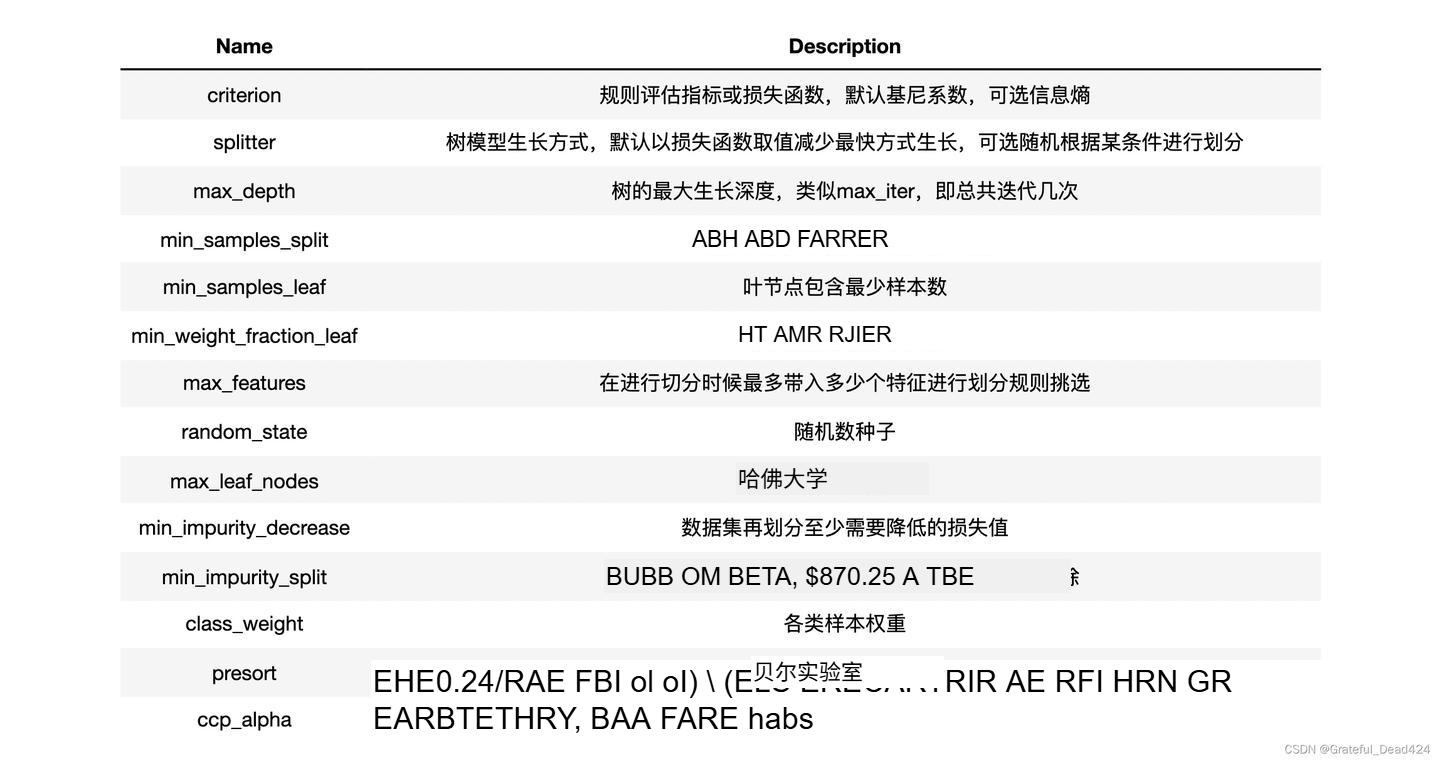

# 测试集上面的效果

Fitting 5 folds for each of 160 candidates, totalling 800 fits
最佳参数： {'class_weight': {0: 1, 1: 5}, 'max_depth': 6, 'min_samples_split': 6}
最佳 recall： 0.5761904761904763

测试集评估报告：
              precision    recall  f1-score   support

           0     0.9661    0.9744    0.9702       117
           1     0.5714    0.5000    0.5333         8

    accuracy                         0.9440       125
   macro avg     0.7688    0.7372    0.7518       125
weighted avg     0.9408    0.9440    0.9423       125



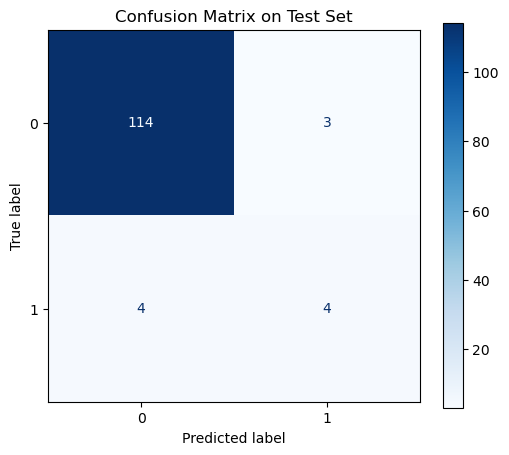


被错分为非1的样本数：4


,name,Ar,VE,AR,EN,Ea,1st,BP,Co,ρ0*λ/10^(-16)Ωm2,class_,original_index,Predicted
133,Cu4W,438.024000,8.901485,165.145745,2.093063,101.695819,755.782724,4091.171169,5.812489,3.590234,1,133,0
277,Co4Os,425.962776,8.553412,166.737414,2.022908,82.635345,795.948430,4131.136645,5.972023,3.583080,1,277,0
16,Ir,192.217000,9.000000,180.000000,2.200000,151.000000,880.000000,4701.000000,6.950000,3.690000,1,16,0
191,CoOs,249.163194,8.236524,177.194692,2.124312,96.071362,821.172652,4791.846467,7.056169,3.559920,1,191,0



被错分为样本数：3


,name,Ar,VE,AR,EN,Ea,1st,BP,Co,ρ0*λ/10^(-16)Ωm2,class_,original_index,Predicted
28,OsRu,291.30000,8.000000,182.571267,2.200000,104.434583,794.964346,4985.918847,7.400000,4.200000,0,28,1
465,Rh3Ru,409.78647,8.753359,174.233203,2.260269,107.628219,717.356914,4080.221494,5.867122,3.405583,0,465,1
57,CuIr,255.76300,9.496913,171.304020,2.125463,142.900316,846.582590,4237.380024,5.863311,4.342351,0,57,1


In [18]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, make_scorer, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# 1. 读取原始数据并添加索引列
df = pd.read_csv('decision tree.csv')
df['original_index'] = df.index  # 保存原始索引以便追踪

# # 删减特征后的dataframe
# df1 = pd.read_csv("decision tree.csv")
# # 删除指定行但保持原始索引
# rows_to_delete = [339,351,354,365,371,375,408,434,511,516,542,605]
# df = df1.drop(rows_to_delete)  # 不使用reset_index
# df['original_index'] = df.index 

# 2. 选择用于建模的特征列和标签列
feature_cols = ['Ar', 'VE', 'EN', 'BP', 'Co']
target_col = df.columns[-2]  # 倒数第二列为标签

# 3. 特征缩放（直接在 DataFrame 中完成）
df_scaled = df.copy()
df_scaled['Ar'] = df_scaled['Ar'] / 100
df_scaled['BP'] = df_scaled['BP'] / 920

# 4. 准备训练数据
X = df_scaled[feature_cols]
y = df_scaled[target_col]

# 5. 分割训练和测试集（保留 DataFrame 格式和原始索引）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
# print(y.shape)
# print(y.value_counts())
# print(y_test.shape)
# print(y_test.value_counts())

# 6. 网格搜索（优化 class_weight）
scorer = make_scorer(recall_score, pos_label=1)
weights = [{0: 1, 1: w} for w in range(2, 6)]
param_grid = {
    'class_weight': weights,
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [3, 4,5,6,7,8,9,10,11,12],
}

clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    clf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_clf = grid_search.best_estimator_

print("最佳参数：", grid_search.best_params_)
print("最佳 recall：", grid_search.best_score_)

# 7. 模型预测 + 错误追踪
best_clf1 = dtc(max_depth=6,min_samples_split=8,max_features=3,class_weight={0:1,1:5},min_impurity_decrease=0)
best_clf = best_clf1.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)
print("\n测试集评估报告：")
print(classification_report(y_test, y_pred, digits=4))

# 8.混淆矩阵用来可视化模型分类情况
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
# 创建可视化对象
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
# 设置颜色映射和标题
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
# 增加标题和坐标说明
ax.set_title("Confusion Matrix on Test Set")
plt.grid(False)
plt.show()

# 9. 找出实际为1但被错分为非1的样本（False Negatives）
false_negatives_mask = (y_test == 1) & (y_pred != 1)
# 恢复原始索引
fn_indices = y_test[false_negatives_mask].index  # 对应 X_test 的行索引
false_negatives_df = df.loc[fn_indices].copy()   # 回到原始 DataFrame 取完整信息
false_negatives_df['Predicted'] = y_pred[false_negatives_mask]
print(f"\n被错分为非1的样本数：{len(false_negatives_df)}")
display(false_negatives_df)

false_negatives_mask1 = (y_test==0)  & (y_pred==1)

# 恢复原始索引
fn_indices1 = y_test[false_negatives_mask1].index  # 对应 X_test 的行索引
false_negatives_df1 = df.loc[fn_indices1].copy()   # 回到原始 DataFrame 取完整信息
false_negatives_df1['Predicted'] = y_pred[false_negatives_mask1]

print(f"\n被错分为样本数：{len(false_negatives_df1)}")
display(false_negatives_df1)



#  ROC曲线检测模型预分类效果    KS统计量用来说明 正负样本的区分度

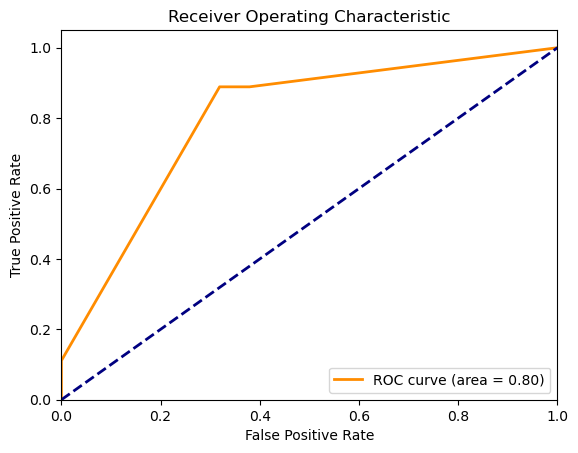

KS Statistic: 0.5699


In [13]:
## import pandas as pd
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# ROC曲线
y_pred_prob= clf.predict_proba(X_test)[:,1]   #预测 0 1 分类的概率
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)   #fpr 真阳性 （正确分类） tpr  假阳性 (错误分类)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# AUC 曲线面积越大越好一般越接近左侧的效果好一点

# KS统计量  常用来检测正负样本区分度  一般来说区分度大于0.4认为区分度还是可以的
ks_stat, p_value = ks_2samp(y_pred_prob[y_test==0], y_pred_prob[y_test==1])
print("KS Statistic: {:.4f}".format(ks_stat))

## 根据训练集和测试集的参数进行参数调整

0.9771428571428571


d:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26641 (\N{CJK UNIFIED IDEOGRAPH-6811}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\py\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


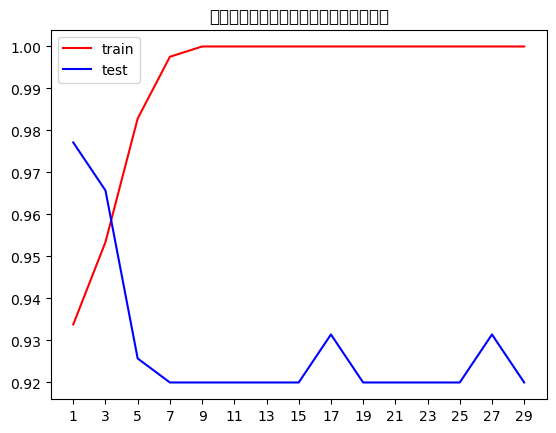

In [3]:
tr,te = [],[]
for i in range(1,30,2):
    clf=dtc(max_depth=i)
    clf=clf.fit(X_train,y_train)
    score_tr=clf.score(X_train,y_train)
    score_te=clf.score(X_test,y_test)
    tr.append(score_tr)
    te.append(score_te)
print(max(te))
plt.plot(range(1,30,2),tr,color='red',label='train')
plt.plot(range(1,30,2),te,color='blue',label='test')
plt.xticks(range(1,30,2))
plt.legend()
plt.title('不同树深度对预测结果与真实类别的影响')
plt.show()



0.9771428571428571


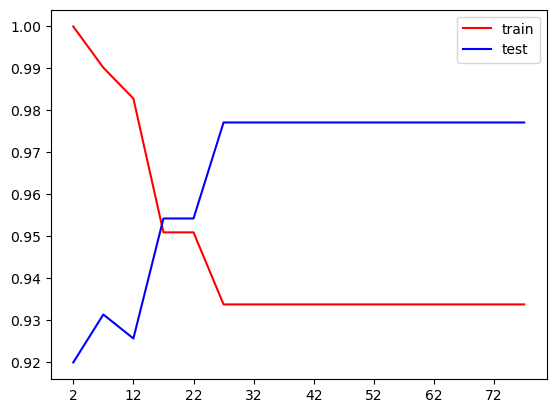

In [4]:
tr1,te1 = [],[]
for i in range(2,80,5):
    clf = dtc(min_samples_split=i)
    clf = clf.fit(X_train, y_train)
    score_tr = clf.score(X_train,y_train)
    score_te = clf.score(X_test,y_test)
    tr1.append(score_tr)
    te1.append(score_te)
print(max(te1))
plt.plot(range(2,80,5),tr1,color="red",label="train")
plt.plot(range(2,80,5),te1,color="blue",label="test")
plt.xticks(range(2,80,5)[::2])
plt.legend()
plt.show()